# TinyLlama Layer-Combination Comparison — Legal QA

This notebook runs **6 selective layer-fine-tuning experiments** on TinyLlama and
compares which layer combination gives the biggest surge in **Training Accuracy**
and **BERTScore F1** over the zero-shot baseline.

## Combinations Tested
| # | Name | Human Layers | Rationale |
|---|------|-------------|-----------|
| 1 | Layer 1 Only | [1] | Minimal single-layer baseline |
| 2 | Layers 1 & 2 | [1,2] | Sequential bottom-2 baseline |
| 3 | Attention-Heavy Zone | [8,9,10,11,12] | Most attention heads active |
| 4 | Alternating Odd | [1,3,5,7,9] | Skip-pattern bottom half |
| 5 | Bottom 3 + Top 2 | [1,2,3,21,22] | Both ends; middle frozen |
| 6 | Last 5 Block | [18,19,20,21,22] | Task-specific generation block |

> **Note:** TinyLlama uses zero-based indices internally, so human layer N → index N-1.
> Results are saved to `layer_combination_results.json` after each experiment,
> allowing safe interruption and resumption.

## 0. Install Dependencies

In [ ]:
# Uncomment as needed:
# %pip install -q transformers datasets bert-score sentencepiece accelerate pandas matplotlib requests


## 1. Imports, GPU Check & Experiment Config

In [ ]:
import io, json as json_module, os, random, re, shutil
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
import torch
from bert_score import score as bert_score_fn
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

# ── Model & data config ────────────────────────────────────────────────────────
MODEL_NAME      = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
SYSTEM_PROMPT   = (
    'You are an expert legal contract assistant. '
    'Answer legal contract questions with meaningful legal text and keywords.'
)
RANDOM_SEED     = 42
SAMPLE_FRACTION = 0.40
TRAIN_FRAC      = 0.70
VAL_FRAC        = 0.15
TEST_FRAC       = 0.15
MAX_LENGTH      = 256
ZERO_SHOT_SAMPLES  = 30
TRAIN_EVAL_SAMPLES = 30

USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

RESULTS_FILE = 'layer_combination_results.json'

# ── Layer-combination definitions ─────────────────────────────────────────────
COMBINATIONS = [
    {
        'name'        : 'Layer 1 Only',
        'label'       : 'layer1_only',
        'human_layers': [1],
        'zero_based'  : [0],
        'description' : 'Single-layer baseline; only layer 1 trainable',
    },
    {
        'name'        : 'Layers 1 & 2',
        'label'       : 'layers1_2',
        'human_layers': [1, 2],
        'zero_based'  : [0, 1],
        'description' : 'Sequential bottom-2 baseline',
    },
    {
        'name'        : 'Attention-Heavy Zone',
        'label'       : 'attn_heavy',
        'human_layers': [8, 9, 10, 11, 12],
        'zero_based'  : [7, 8, 9, 10, 11],
        'description' : 'Layers 8-12: most attention heads active',
    },
    {
        'name'        : 'Alternating Odd',
        'label'       : 'alt_odd',
        'human_layers': [1, 3, 5, 7, 9],
        'zero_based'  : [0, 2, 4, 6, 8],
        'description' : 'Layers 1,3,5,7,9: skip-pattern through bottom half',
    },
    {
        'name'        : 'Bottom 3 + Top 2',
        'label'       : 'bot3_top2',
        'human_layers': [1, 2, 3, 21, 22],
        'zero_based'  : [0, 1, 2, 20, 21],
        'description' : 'Layers 1-3 & 21-22: both ends, frozen middle',
    },
    {
        'name'        : 'Last 5 Block',
        'label'       : 'last5',
        'human_layers': [18, 19, 20, 21, 22],
        'zero_based'  : [17, 18, 19, 20, 21],
        'description' : 'Layers 18-22: task-specific generation block',
    },
]

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))
    print('VRAM            :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
print('Use bf16        :', USE_BF16)
print('Use fp16        :', USE_FP16)
print(f'\n{len(COMBINATIONS)} combinations queued:')
for i, c in enumerate(COMBINATIONS):
    print(f'  {i+1}. {c["name"]:25s} → layers {c["human_layers"]}')


d:\devatry2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.10.0+cu126
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM            : 6.44 GB
Use bf16        : True
Use fp16        : False

6 combinations queued:
  1. Layer 1 Only              → layers [1]
  2. Layers 1 & 2              → layers [1, 2]
  3. Attention-Heavy Zone      → layers [8, 9, 10, 11, 12]
  4. Alternating Odd           → layers [1, 3, 5, 7, 9]
  5. Bottom 3 + Top 2          → layers [1, 2, 3, 21, 22]
  6. Last 5 Block              → layers [18, 19, 20, 21, 22]


## 2. Load & Build the 40 % Dataset

In [ ]:
def clean_text(val):
    if pd.isna(val) or str(val).strip() in ['', '[]', 'nan']:
        return None
    val = str(val).strip()
    val = re.sub(r'^\[|\]$', '', val)
    val = re.sub(r"^'+|'+$", '', val)
    return val.strip() or None

with open('cuad.json', 'r', encoding='utf-8') as f:
    cuad = json_module.load(f, strict=False)
print(f'cuad.json contracts : {len(cuad["data"])}')

CSV_URL = 'https://huggingface.co/datasets/theatticusproject/cuad/resolve/main/CUAD_v1/master_clauses.csv'
print('Downloading master_clauses.csv...')
response = requests.get(CSV_URL, timeout=60)
response.raise_for_status()
df = pd.read_csv(io.StringIO(response.text))
print(f'CSV shape           : {df.shape}')

all_examples = []

for article in cuad['data']:
    for paragraph in article['paragraphs']:
        for qa in paragraph['qas']:
            question = qa['question']
            answer   = qa['answers'][0]['text'] if qa['answers'] else ''
            question = question.replace('Highlight the parts (if any) of this contract related to', '')
            question = question.replace('that should be reviewed by a lawyer.', '')
            question = re.sub(r'"[^"]*"\s*', '', question)
            question = question.replace('Details:', '').strip()
            if not answer:
                continue
            if answer.strip().lower() in ['yes', 'no']:
                continue
            if len(answer.split()) < 5:
                continue
            answer = answer[:300].strip()
            text = (
                f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
                f'<|user|>\n{question}</s>\n'
                f'<|assistant|>\n{answer}</s>'
            )
            all_examples.append({'question': question, 'answer': answer,
                                  'text': text, 'source': 'cuad_json'})

CLAUSE_NAMES = [
    'Governing Law', 'Parties', 'Renewal Term',
    'Notice Period To Terminate Renewal', 'Expiration Date',
    'Effective Date', 'Agreement Date', 'Termination For Convenience',
    'Anti-Assignment', 'License Grant', 'Audit Rights',
    'Cap On Liability', 'Liquidated Damages', 'Warranty Duration',
    'Insurance', 'Ip Ownership Assignment', 'Minimum Commitment',
    'Post-Termination Services', 'Non-Compete', 'Exclusivity',
    'Change Of Control', 'Source Code Escrow',
]

csv_count = 0
for _, row in df.iterrows():
    for clause in CLAUSE_NAMES:
        clause_text = clean_text(row.get(clause))
        if clause_text is None:
            continue
        if clause_text.strip().lower() in ['yes', 'no']:
            continue
        if len(clause_text.split()) < 5:
            continue
        clause_text = clause_text[:300].strip()
        question = f'What is the {clause} clause in a legal contract?'
        text = (
            f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
            f'<|user|>\n{question}</s>\n'
            f'<|assistant|>\n{clause_text}</s>'
        )
        all_examples.append({'question': question, 'answer': clause_text,
                              'text': text, 'source': 'csv'})
        csv_count += 1

print(f'From CSV             : {csv_count}')
print(f'Total combined        : {len(all_examples)}')

random.shuffle(all_examples)
sample_size  = int(len(all_examples) * SAMPLE_FRACTION)
sampled      = all_examples[:sample_size]
train_end    = int(sample_size * TRAIN_FRAC)
val_end      = train_end + int(sample_size * VAL_FRAC)
train_examples = sampled[:train_end]
val_examples   = sampled[train_end:val_end]
test_examples  = sampled[val_end:]

assert len(train_examples) + len(val_examples) + len(test_examples) == sample_size

print(f'40% sample   : {sample_size}')
print(f'Train        : {len(train_examples)}')
print(f'Validation   : {len(val_examples)}')
print(f'Test         : {len(test_examples)}')


cuad.json contracts : 510
CSV shape           : (510, 83)
From CSV             : 4505
Total combined        : 9833
40% sample   : 3933
Train        : 2753
Validation   : 589
Test         : 591


## 3. Tokenizer & Helper Functions

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.padding_side = 'right'
print('Tokenizer loaded. Vocab size:', len(tokenizer))

# ── Text utilities ────────────────────────────────────────────────────────────
def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'[^\w\s]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

def token_f1(pred, gold):
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def split_prompt_answer(text):
    marker      = '<|assistant|>\n'
    prompt_part, answer_part = text.split(marker, 1)
    prompt_text = prompt_part + marker
    answer_text = answer_part.rsplit('</s>', 1)[0].strip()
    return prompt_text, answer_text

# ── Tokenization ──────────────────────────────────────────────────────────────
def tokenize_fn(example):
    prompt_text, answer_text = split_prompt_answer(example['text'])
    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )['input_ids']
    answer_ids = tokenizer(
        answer_text + tokenizer.eos_token,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )['input_ids']
    available_for_answer = MAX_LENGTH - len(prompt_ids)
    if available_for_answer <= 0:
        prompt_ids = prompt_ids[:max(1, MAX_LENGTH - 1)]
        available_for_answer = MAX_LENGTH - len(prompt_ids)
    answer_ids  = answer_ids[:max(0, available_for_answer)]
    input_ids   = prompt_ids + answer_ids
    attention_mask = [1] * len(input_ids)
    labels      = [-100] * len(prompt_ids) + answer_ids
    pad_len = MAX_LENGTH - len(input_ids)
    if pad_len > 0:
        input_ids      += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        labels         += [-100] * pad_len
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

# ── Model inference ───────────────────────────────────────────────────────────
def ask_legal(model, question, max_new_tokens=100):
    prompt = (
        f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
        f'<|user|>\n{question}</s>\n'
        f'<|assistant|>\n'
    )
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
    ).to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()

# ── BERTScore + Token F1 evaluation ──────────────────────────────────────────
def evaluate_model(model, examples, num_samples=30):
    model.eval()
    sample_count = min(num_samples, len(examples))
    if sample_count == 0:
        return {'num_samples': 0, 'bert_p': 0., 'bert_r': 0., 'bert_f1': 0., 'token_f1': 0.}
    samples     = random.sample(examples, sample_count)
    predictions = [ask_legal(model, ex['question']) for ex in samples]
    golds       = [ex['answer'] for ex in samples]
    precision, recall, f1 = bert_score_fn(
        predictions, golds, lang='en',
        rescale_with_baseline=False, verbose=False,
    )
    avg_token_f1 = sum(token_f1(p, g) for p, g in zip(predictions, golds)) / sample_count * 100
    return {
        'num_samples': sample_count,
        'bert_p'   : round(precision.mean().item() * 100, 2),
        'bert_r'   : round(recall.mean().item() * 100, 2),
        'bert_f1'  : round(f1.mean().item() * 100, 2),
        'token_f1' : round(avg_token_f1, 2),
    }

# ── Per-split token accuracy ──────────────────────────────────────────────────
def _sample_to_tensors(sample):
    input_ids      = torch.tensor(sample['input_ids'],      dtype=torch.long).unsqueeze(0)
    attention_mask = torch.tensor(sample['attention_mask'], dtype=torch.long).unsqueeze(0)
    labels         = torch.tensor(sample['labels'],         dtype=torch.long).unsqueeze(0)
    return input_ids, attention_mask, labels

def compute_split_token_accuracy(model, dataset_split):
    model.eval()
    total_correct = 0
    total_tokens  = 0
    with torch.no_grad():
        for sample in dataset_split:
            input_ids, attention_mask, labels = _sample_to_tensors(sample)
            input_ids      = input_ids.to('cuda')
            attention_mask = attention_mask.to('cuda')
            labels         = labels.to('cuda')
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            shift_logits   = outputs.logits[:, :-1, :]
            shift_labels   = labels[:, 1:]
            preds          = torch.argmax(shift_logits, dim=-1)
            mask           = shift_labels != -100
            total_correct += ((preds == shift_labels) & mask).sum().item()
            total_tokens  += mask.sum().item()
            del input_ids, attention_mask, labels, outputs, shift_logits, shift_labels, preds, mask
            torch.cuda.empty_cache()
    return 0.0 if total_tokens == 0 else total_correct / total_tokens

def latest_checkpoint(output_dir):
    path = Path(output_dir)
    if not path.exists():
        return None
    checkpoints = [p for p in path.iterdir() if p.is_dir() and p.name.startswith('checkpoint-')]
    if not checkpoints:
        return None
    return str(max(checkpoints, key=lambda p: int(p.name.split('-')[-1])))


Tokenizer loaded. Vocab size: 32001


## 4. Build Hugging Face Datasets

In [ ]:
dataset = DatasetDict({
    'train'     : Dataset.from_list([{'text': x['text']} for x in train_examples]),
    'validation': Dataset.from_list([{'text': x['text']} for x in val_examples]),
    'test'      : Dataset.from_list([{'text': x['text']} for x in test_examples]),
})
tokenized = dataset.map(tokenize_fn, remove_columns=['text'])
print(tokenized)


Map: 100%|██████████| 591/591 [00:00<00:00, 2557.51 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2753
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 589
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 591
    })
})


In [ ]:
# ============================================================
# INPUT DIMENSION 
# ============================================================

import torch

sample = tokenized['train'][0]

input_ids      = torch.tensor(sample['input_ids'])
attention_mask = torch.tensor(sample['attention_mask'])
labels         = torch.tensor(sample['labels'])

print("=" * 55)
print("INPUT DIMENSION FULL ANALYSIS")
print("=" * 55)

print("\nSingle Sample Shapes:")
print(f"  input_ids      : {list(input_ids.shape)}  -> {input_ids.dtype}")
print(f"  attention_mask : {list(attention_mask.shape)}  -> {attention_mask.dtype}")
print(f"  labels         : {list(labels.shape)}  -> {labels.dtype}")

print("\nBatched Shape (batch_size = 1):")
print(f"  input_ids      : {list(input_ids.unsqueeze(0).shape)}")
print(f"  attention_mask : {list(attention_mask.unsqueeze(0).shape)}")
print(f"  labels         : {list(labels.unsqueeze(0).shape)}")

print("\nToken Breakdown:")
print(f"  MAX_LENGTH              : {len(input_ids)}")
print(f"  Real tokens             : {(attention_mask == 1).sum().item()}")
print(f"  Pad tokens              : {(attention_mask == 0).sum().item()}")
print(f"  Prompt tokens (-100)    : {(labels == -100).sum().item()}")
print(f"  Supervised tokens       : {(labels != -100).sum().item()}")

print("\nModel Output Shapes:")
vocab_size = len(tokenizer)
print(f"  logits       : [1, {len(input_ids)}, {vocab_size}]")
print(f"  shift_logits : [1, {len(input_ids)-1}, {vocab_size}]")
print(f"  shift_labels : [1, {len(input_ids)-1}]")

print("\nDataset Split Sizes:")
for split in ['train', 'validation', 'test']:
    print(f"  {split:12s}: {len(tokenized[split]):>6,} samples")

print(f"\nTokenizer Vocab Size: {vocab_size}")

# ============================================================
# HOW 256 x 2048 LOOKS
# ============================================================

print("\nExample: Tensor of shape [256, 2048]")

example = torch.zeros((256, 2048), dtype=torch.int32)

print(f"Shape: {list(example.shape)}")

print("\nInterpretation:")
print("  256 rows  -> batch size (256 sequences)")
print("  2048 cols -> tokens per sequence (context length)")

print("\nFirst row (truncated):")
print(example[0][:20])  # show first 20 tokens

print("\nLast row (truncated):")
print(example[-1][:20])

print("\nMemory usage (approx):")
bytes_used = example.numel() * example.element_size()
print(f"  {bytes_used / (1024**2):.2f} MB")

print("=" * 55)

INPUT DIMENSION FULL ANALYSIS

Single Sample Shapes:
  input_ids      : [256]  -> torch.int64
  attention_mask : [256]  -> torch.int64
  labels         : [256]  -> torch.int64

Batched Shape (batch_size = 1):
  input_ids      : [1, 256]
  attention_mask : [1, 256]
  labels         : [1, 256]

Token Breakdown:
  MAX_LENGTH              : 256
  Real tokens             : 130
  Pad tokens              : 126
  Prompt tokens (-100)    : 182
  Supervised tokens       : 74

Model Output Shapes:
  logits       : [1, 256, 32001]
  shift_logits : [1, 255, 32001]
  shift_labels : [1, 255]

Dataset Split Sizes:
  train       :  2,753 samples
  validation  :    589 samples
  test        :    591 samples

Tokenizer Vocab Size: 32001

Example: Tensor of shape [256, 2048]
Shape: [256, 2048]

Interpretation:
  256 rows  -> batch size (256 sequences)
  2048 cols -> tokens per sequence (context length)

First row (truncated):
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       dtyp

## 5. Zero-Shot Baseline (Shared Across All Experiments)

In [ ]:
print('Loading base model for zero-shot baseline...')
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
).to('cuda')
base_model.resize_token_embeddings(len(tokenizer))
base_model.config.use_cache = True
base_model.eval()

zero_shot_metrics  = evaluate_model(base_model, test_examples, num_samples=ZERO_SHOT_SAMPLES)
ZERO_SHOT_BERT_F1  = zero_shot_metrics['bert_f1']
ZERO_SHOT_TOKEN_F1 = zero_shot_metrics['token_f1']

print(f'Zero-shot samples     : {zero_shot_metrics["num_samples"]}')
print(f'Zero-shot BERTScore F1: {ZERO_SHOT_BERT_F1}%')
print(f'Zero-shot Token F1    : {ZERO_SHOT_TOKEN_F1}%')

del base_model
torch.cuda.empty_cache()
print('Zero-shot baseline done. GPU memory cleared.')


Loading base model for zero-shot baseline...


Loading weights: 100%|██████████| 201/201 [00:02<00:00, 100.38it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more informatio

OSError: The paging file is too small for this operation to complete. (os error 1455)

## 6. Training Function

The function loads a **fresh** TinyLlama, freezes all layers, unfreezes only
the target layers (+ `model.norm` + `lm_head`), trains, evaluates, then clears
GPU memory before returning the result dict.

In [ ]:
def run_experiment(combo):
    """Train one layer-combination experiment and return its result dict."""
    label        = combo['label']
    human_layers = combo['human_layers']
    zero_based   = combo['zero_based']

    output_dir = f'output_{label}'
    model_dir  = f'tinyllama_{label}'
    log_dir    = f'tb_logs_{label}'

    print(f'\n{"="*65}')
    print(f'EXPERIMENT: {combo["name"]}')
    print(f'  Human layers : {human_layers}')
    print(f'  Zero-indexed : {zero_based}')
    print(f'  Description  : {combo["description"]}')
    print(f'{"="*65}')

    # ── Load fresh base model ────────────────────────────────────────────────
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, low_cpu_mem_usage=True,
    ).to('cuda')
    model.resize_token_embeddings(len(tokenizer))
    model.config.use_cache = False

    # ── Freeze all params, then selectively unfreeze ─────────────────────────
    for param in model.parameters():
        param.requires_grad = False
    for idx in zero_based:
        for param in model.model.layers[idx].parameters():
            param.requires_grad = True
    for param in model.model.norm.parameters():
        param.requires_grad = True
    for param in model.lm_head.parameters():
        param.requires_grad = True

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable params: {trainable_params:,} / {total_params:,}'
          f' ({100 * trainable_params / total_params:.2f}%)')

    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()

    # ── TrainingArguments ────────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=8,
        num_train_epochs=4,
        learning_rate=1e-4,
        lr_scheduler_type='cosine',
        warmup_ratio=0.05,
        weight_decay=0.02,
        fp16=USE_FP16,
        bf16=USE_BF16,
        optim='adamw_torch',
        logging_dir=log_dir,
        logging_steps=10,
        logging_strategy='steps',
        eval_strategy='steps',
        eval_steps=100,
        save_strategy='steps',
        save_steps=100,
        save_total_limit=1,
        eval_accumulation_steps=1,
        prediction_loss_only=True,
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        remove_unused_columns=False,
        report_to=[],
        seed=RANDOM_SEED,
        data_seed=RANDOM_SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        callbacks=[],
    )

    # ── Resume if checkpoint exists ──────────────────────────────────────────
    resume_ckpt = latest_checkpoint(output_dir)
    if resume_ckpt:
        print(f'Resuming from: {resume_ckpt}')
        train_result = trainer.train(resume_from_checkpoint=resume_ckpt)
    else:
        train_result = trainer.train()

    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f'Steps completed: {train_result.global_step}')
    print(f'Reported train loss: {train_result.training_loss:.4f}')

    # ── Evaluate ─────────────────────────────────────────────────────────────
    model.config.use_cache = True
    ft_metrics = evaluate_model(model, test_examples, num_samples=TRAIN_EVAL_SAMPLES)

    train_acc = compute_split_token_accuracy(model, tokenized['train']) * 100
    val_acc   = compute_split_token_accuracy(model, tokenized['validation']) * 100
    test_acc  = compute_split_token_accuracy(model, tokenized['test']) * 100

    # ── Extract loss history ─────────────────────────────────────────────────
    history     = trainer.state.log_history
    train_steps  = [e['step']      for e in history if 'loss'      in e and 'eval_loss' not in e]
    train_losses = [e['loss']      for e in history if 'loss'      in e and 'eval_loss' not in e]
    eval_steps   = [e['step']      for e in history if 'eval_loss' in e]
    eval_losses  = [e['eval_loss'] for e in history if 'eval_loss' in e]

    result = {
        'name'               : combo['name'],
        'label'              : label,
        'human_layers'       : human_layers,
        'description'        : combo['description'],
        'bert_f1'            : ft_metrics['bert_f1'],
        'bert_p'             : ft_metrics['bert_p'],
        'bert_r'             : ft_metrics['bert_r'],
        'token_f1'           : ft_metrics['token_f1'],
        'train_token_acc'    : round(train_acc, 2),
        'val_token_acc'      : round(val_acc, 2),
        'test_token_acc'     : round(test_acc, 2),
        'reported_train_loss': round(train_result.training_loss, 4),
        'train_steps'        : train_steps,
        'train_losses'       : train_losses,
        'eval_steps'         : eval_steps,
        'eval_losses'        : eval_losses,
    }

    # ── Cleanup GPU ──────────────────────────────────────────────────────────
    del model, trainer
    torch.cuda.empty_cache()
    print(f'GPU cleared. BERTScore F1: {ft_metrics["bert_f1"]}%  '
          f'Train Acc: {train_acc:.2f}%')
    return result


## 7. Run All Experiments

Results are persisted to `layer_combination_results.json` after each run.
If the kernel crashes, re-run this cell and already-completed experiments will be skipped.

In [ ]:
# ── Load existing results (for resume) ───────────────────────────────────────
if Path(RESULTS_FILE).exists():
    with open(RESULTS_FILE, 'r', encoding='utf-8') as f:
        all_results = json_module.load(f)
    completed_labels = {r['label'] for r in all_results}
    print(f'Loaded {len(all_results)} existing result(s): {completed_labels}')
else:
    all_results      = []
    completed_labels = set()

# ── Run each experiment sequentially ─────────────────────────────────────────
for combo in COMBINATIONS:
    if combo['label'] in completed_labels:
        print(f'[SKIP] {combo["name"]} — already completed.')
        continue

    result = run_experiment(combo)
    all_results.append(result)
    completed_labels.add(result['label'])

    with open(RESULTS_FILE, 'w', encoding='utf-8') as f:
        json_module.dump(all_results, f, indent=2)
    print(f'  Saved to {RESULTS_FILE}')

print(f'\nAll {len(all_results)}/{len(COMBINATIONS)} experiments complete!')


Loaded 6 existing result(s): {'last5', 'layer1_only', 'attn_heavy', 'bot3_top2', 'alt_odd', 'layers1_2'}
[SKIP] Layer 1 Only — already completed.
[SKIP] Layers 1 & 2 — already completed.
[SKIP] Attention-Heavy Zone — already completed.
[SKIP] Alternating Odd — already completed.
[SKIP] Bottom 3 + Top 2 — already completed.
[SKIP] Last 5 Block — already completed.

All 6/6 experiments complete!


## 8. Results Table & Winner Analysis

In [ ]:
# ── Build summary DataFrame ──────────────────────────────────────────────────
rows = []
for r in all_results:
    rows.append({
        'Combination'      : r['name'],
        'Layers (human)'   : str(r['human_layers']),
        'BERTScore F1 (%)'  : r['bert_f1'],
        'BERT Δ vs Zero-Shot': round(r['bert_f1'] - ZERO_SHOT_BERT_F1, 2),
        'Token F1 (%)'      : r['token_f1'],
        'Train Acc (%)'     : r['train_token_acc'],
        'Val Acc (%)'       : r['val_token_acc'],
        'Test Acc (%)'      : r['test_token_acc'],
        'Train Loss'        : r['reported_train_loss'],
    })

df_res = pd.DataFrame(rows)

# Sort by BERTScore F1 descending
df_res_sorted = df_res.sort_values('BERTScore F1 (%)', ascending=False).reset_index(drop=True)

print('\n=== Results Table (sorted by BERTScore F1) ===')
print(df_res_sorted.to_string(index=False))

# ── Winner identification ─────────────────────────────────────────────────────
best_bert   = max(all_results, key=lambda r: r['bert_f1'])
best_train  = max(all_results, key=lambda r: r['train_token_acc'])
best_delta  = max(all_results, key=lambda r: r['bert_f1'] - ZERO_SHOT_BERT_F1)

print(f'\n>>> Best BERTScore F1 : {best_bert["name"]} ({best_bert["bert_f1"]}%)')
print(f'>>> Best Train Acc    : {best_train["name"]} ({best_train["train_token_acc"]}%)')
print(f'>>> Largest BERT Surge: {best_delta["name"]} '
      f'(+{best_delta["bert_f1"]-ZERO_SHOT_BERT_F1:.2f}% over zero-shot)')



=== Results Table (sorted by BERTScore F1) ===
         Combination       Layers (human)  BERTScore F1 (%)  BERT Δ vs Zero-Shot  Token F1 (%)  Train Acc (%)  Val Acc (%)  Test Acc (%)  Train Loss
     Alternating Odd      [1, 3, 5, 7, 9]             84.32                 2.06         30.26          77.66        64.21         65.24      1.0624
        Layer 1 Only                  [1]             84.19                 1.93         30.76          70.20        62.87         63.89      1.4729
        Layers 1 & 2               [1, 2]             83.84                 1.58         29.40          75.07        63.81         64.57      1.3417
    Bottom 3 + Top 2    [1, 2, 3, 21, 22]             83.79                 1.53         27.63          78.25        63.73         64.73      1.0373
        Last 5 Block [18, 19, 20, 21, 22]             83.48                 1.22         28.16          82.30        63.36         64.25      0.9347
Attention-Heavy Zone   [8, 9, 10, 11, 12]             83.2

## 9. Plot 1 — BERTScore F1 Comparison

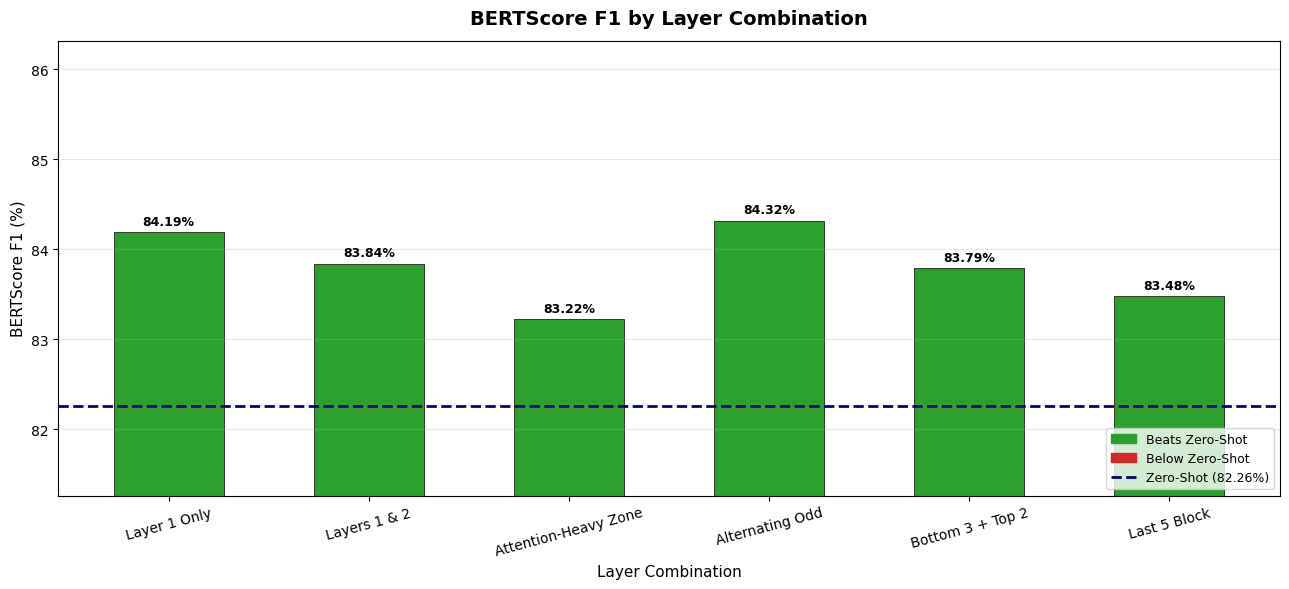

Saved: comparison_bert_f1.png


In [ ]:
names     = [r['name']     for r in all_results]
bert_f1s  = [r['bert_f1']  for r in all_results]

colors = ['#2ca02c' if v > ZERO_SHOT_BERT_F1 else '#d62728' for v in bert_f1s]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(names, bert_f1s, color=colors, edgecolor='black', linewidth=0.5, width=0.55)

ax.axhline(ZERO_SHOT_BERT_F1, color='navy', linestyle='--', linewidth=2,
           label=f'Zero-Shot Baseline ({ZERO_SHOT_BERT_F1}%)')

for bar, val in zip(bars, bert_f1s):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('BERTScore F1 by Layer Combination', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('BERTScore F1 (%)', fontsize=11)
ax.set_xlabel('Layer Combination', fontsize=11)
ax.tick_params(axis='x', rotation=15)

green_patch = mpatches.Patch(color='#2ca02c', label='Beats Zero-Shot')
red_patch   = mpatches.Patch(color='#d62728', label='Below Zero-Shot')
ax.legend(handles=[green_patch, red_patch,
          plt.Line2D([0],[0], color='navy', linestyle='--', linewidth=2,
                     label=f'Zero-Shot ({ZERO_SHOT_BERT_F1}%)')],
          fontsize=9, loc='lower right')

y_min = min(bert_f1s + [ZERO_SHOT_BERT_F1]) - 1
y_max = max(bert_f1s + [ZERO_SHOT_BERT_F1]) + 2
ax.set_ylim(y_min, y_max)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_bert_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_bert_f1.png')


## 10. Plot 2 — Token F1 Comparison

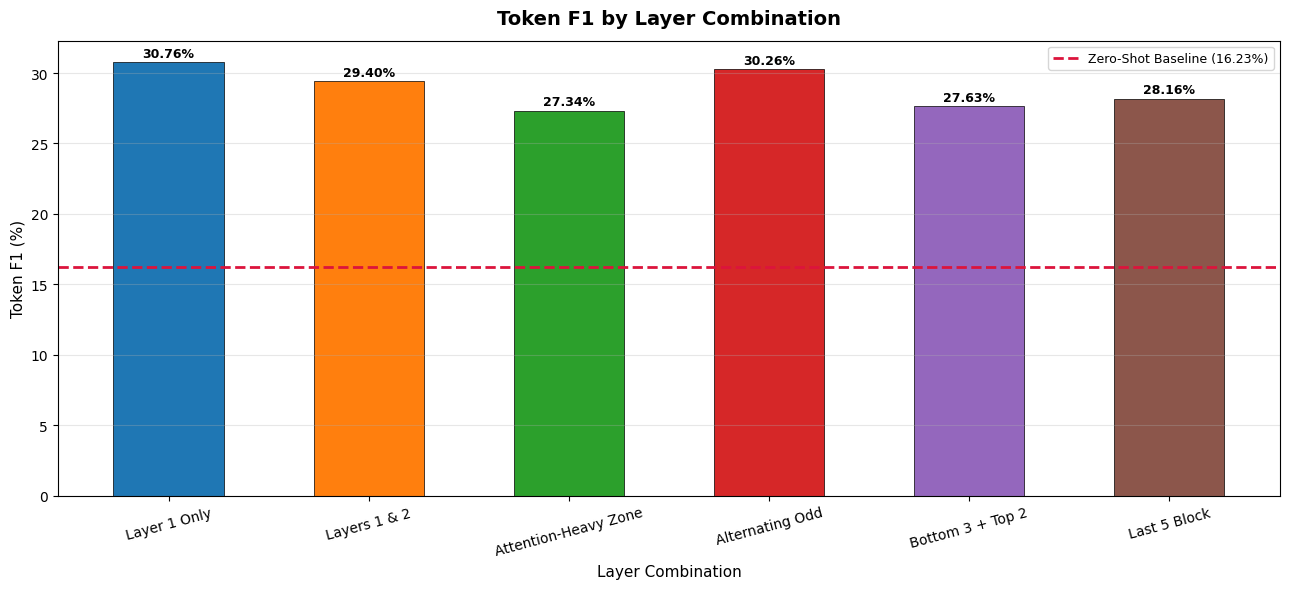

Saved: comparison_token_f1.png


In [ ]:
token_f1s = [r['token_f1'] for r in all_results]

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = plt.cm.tab10.colors[:len(names)]
bars = ax.bar(names, token_f1s, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.55)

ax.axhline(ZERO_SHOT_TOKEN_F1, color='crimson', linestyle='--', linewidth=2,
           label=f'Zero-Shot Baseline ({ZERO_SHOT_TOKEN_F1}%)')

for bar, val in zip(bars, token_f1s):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Token F1 by Layer Combination', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Token F1 (%)', fontsize=11)
ax.set_xlabel('Layer Combination', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_token_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_token_f1.png')


## 11. Plot 3 — Training Token Accuracy

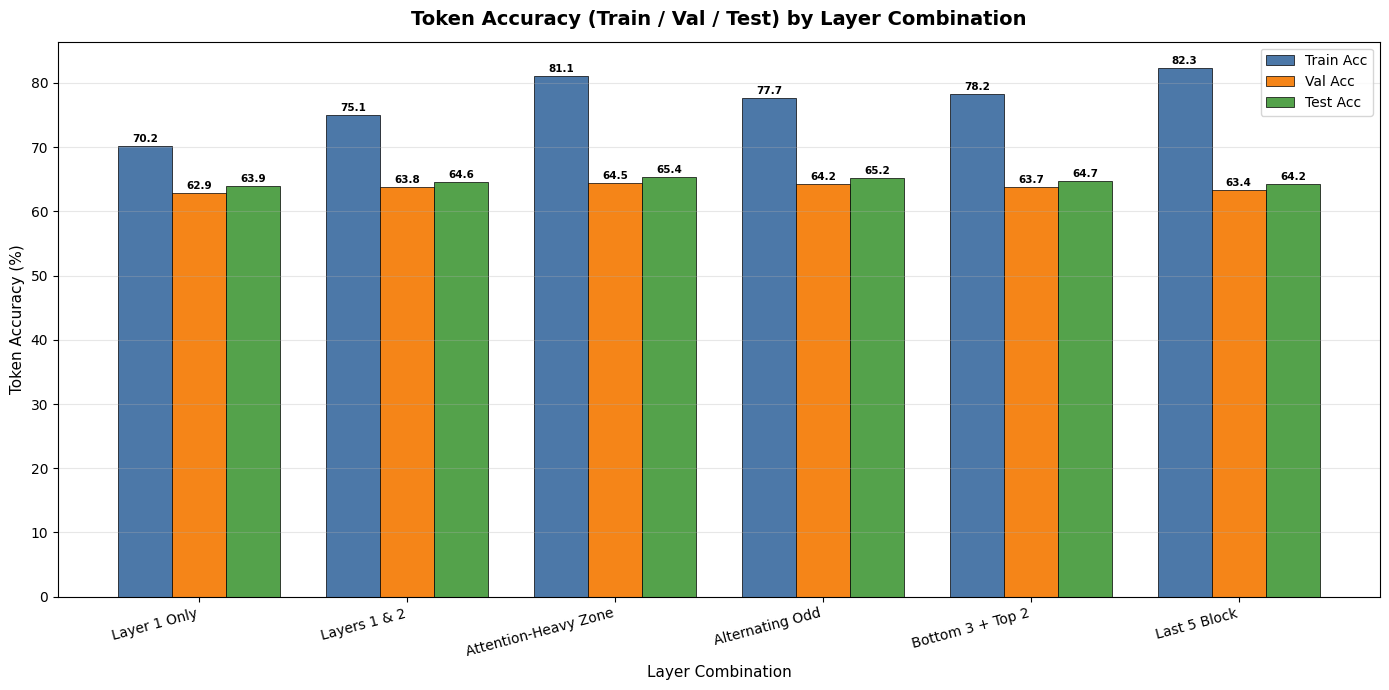

Saved: comparison_accuracy.png


In [ ]:
train_accs = [r['train_token_acc'] for r in all_results]
val_accs   = [r['val_token_acc']   for r in all_results]
test_accs  = [r['test_token_acc']  for r in all_results]

x     = np.arange(len(names))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.bar(x - width, train_accs, width, label='Train Acc', color='#4c78a8', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,         val_accs,   width, label='Val Acc',   color='#f58518', edgecolor='black', linewidth=0.5)
b3 = ax.bar(x + width, test_accs,  width, label='Test Acc',  color='#54a24b', edgecolor='black', linewidth=0.5)

for bar, val in zip(b1, train_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
for bar, val in zip(b2, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
for bar, val in zip(b3, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_title('Token Accuracy (Train / Val / Test) by Layer Combination',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Token Accuracy (%)', fontsize=11)
ax.set_xlabel('Layer Combination', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_accuracy.png')


## 12. Plot 4 — Surge Over Zero-Shot Baseline

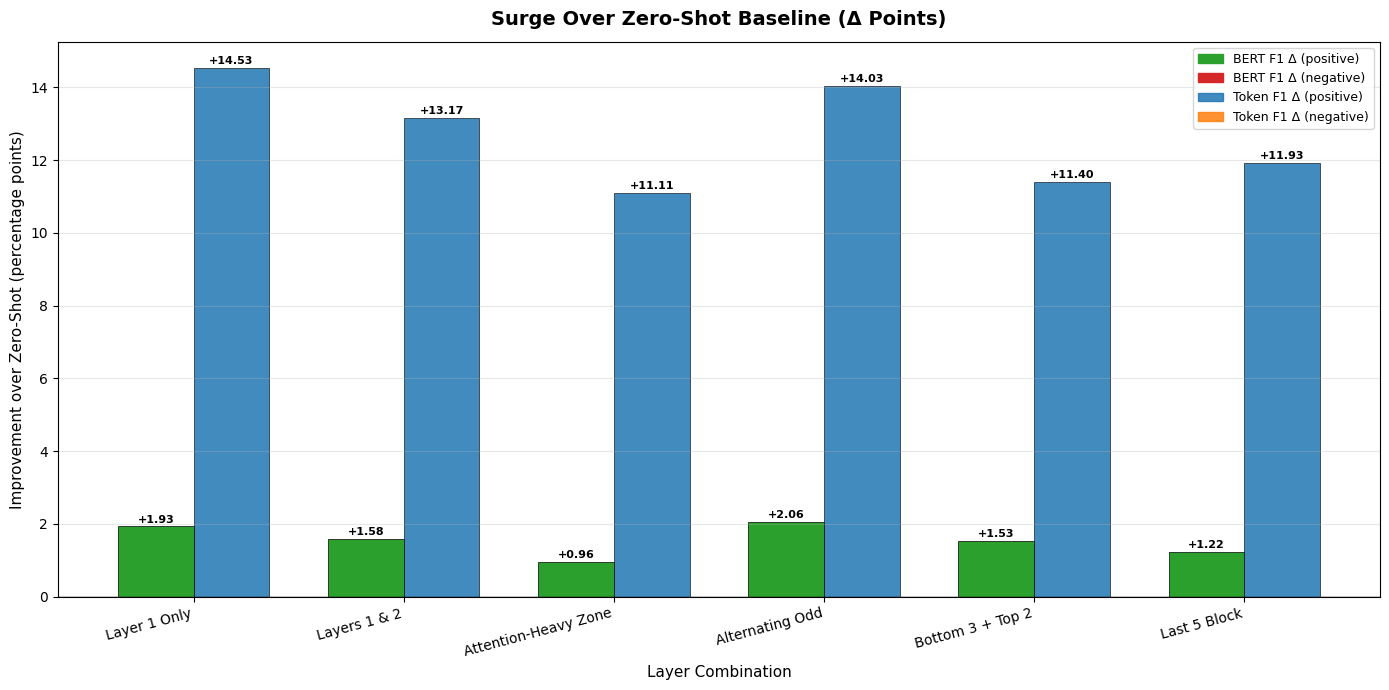

Saved: comparison_surge.png


In [ ]:
delta_bert  = [r['bert_f1']  - ZERO_SHOT_BERT_F1  for r in all_results]
delta_token = [r['token_f1'] - ZERO_SHOT_TOKEN_F1 for r in all_results]

x     = np.arange(len(names))
width = 0.36

fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.bar(x - width/2, delta_bert,  width,
            label='BERT F1 Δ',  color=['#2ca02c' if v >= 0 else '#d62728' for v in delta_bert],
            edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, delta_token, width,
            label='Token F1 Δ', color=['#1f77b4' if v >= 0 else '#ff7f0e' for v in delta_token],
            edgecolor='black', linewidth=0.5, alpha=0.85)

for bar, val in zip(b1, delta_bert):
    ypos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(b2, delta_token):
    ypos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_title('Surge Over Zero-Shot Baseline (Δ Points)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Improvement over Zero-Shot (percentage points)', fontsize=11)
ax.set_xlabel('Layer Combination', fontsize=11)

green_p = mpatches.Patch(color='#2ca02c', label='BERT F1 Δ (positive)')
red_p   = mpatches.Patch(color='#d62728', label='BERT F1 Δ (negative)')
blue_p  = mpatches.Patch(color='#1f77b4', label='Token F1 Δ (positive)', alpha=0.85)
ora_p   = mpatches.Patch(color='#ff7f0e', label='Token F1 Δ (negative)', alpha=0.85)
ax.legend(handles=[green_p, red_p, blue_p, ora_p], fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_surge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_surge.png')


## 13. Plot 5 — Training & Validation Loss Curves (per experiment)

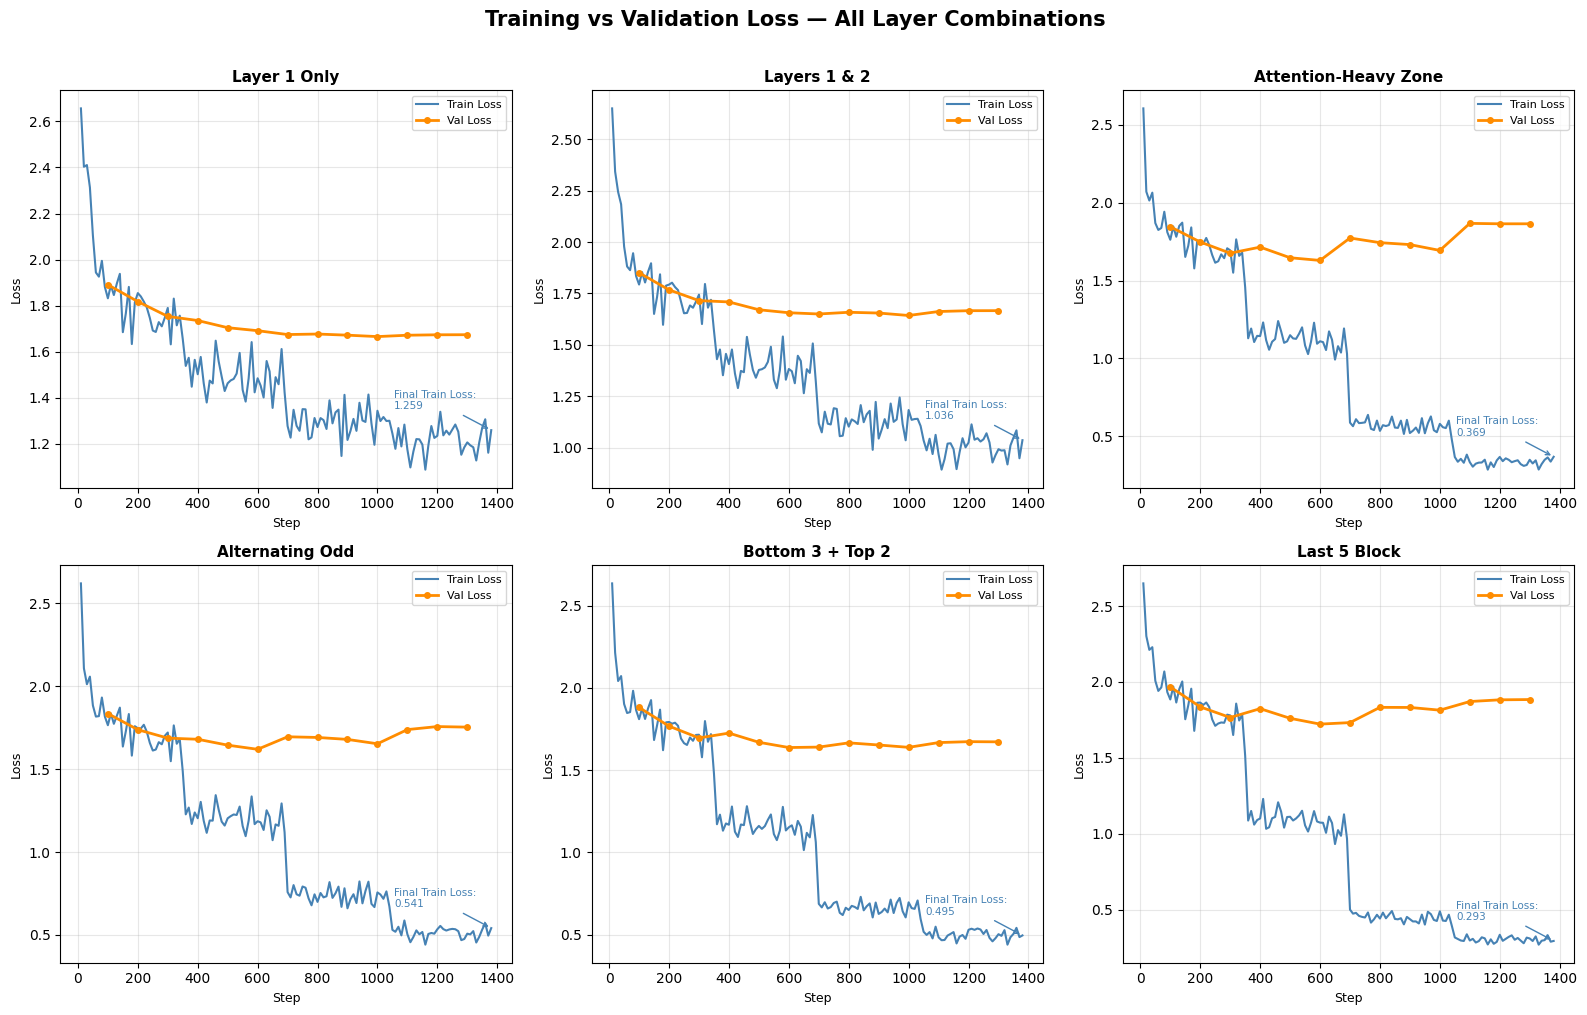

Saved: comparison_loss_curves.png


In [ ]:
n_exps = len(all_results)
ncols  = 3
nrows  = (n_exps + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, r in enumerate(all_results):
    ax = axes[i]
    if r['train_steps'] and r['train_losses']:
        ax.plot(r['train_steps'], r['train_losses'],
                color='steelblue', linewidth=1.5, label='Train Loss')
    if r['eval_steps'] and r['eval_losses']:
        ax.plot(r['eval_steps'], r['eval_losses'],
                color='darkorange', linewidth=2, marker='o',
                markersize=4, label='Val Loss')

    ax.set_title(r['name'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Step', fontsize=9)
    ax.set_ylabel('Loss', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotate final train loss
    if r['train_losses']:
        ax.annotate(f"Final Train Loss:\n{r['train_losses'][-1]:.3f}",
                    xy=(r['train_steps'][-1], r['train_losses'][-1]),
                    xytext=(-70, 15), textcoords='offset points',
                    fontsize=7.5, color='steelblue',
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))

# Hide unused axes
for j in range(n_exps, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Training vs Validation Loss — All Layer Combinations',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_loss_curves.png')


## 14. Plot 6 — Multi-Metric Radar Chart

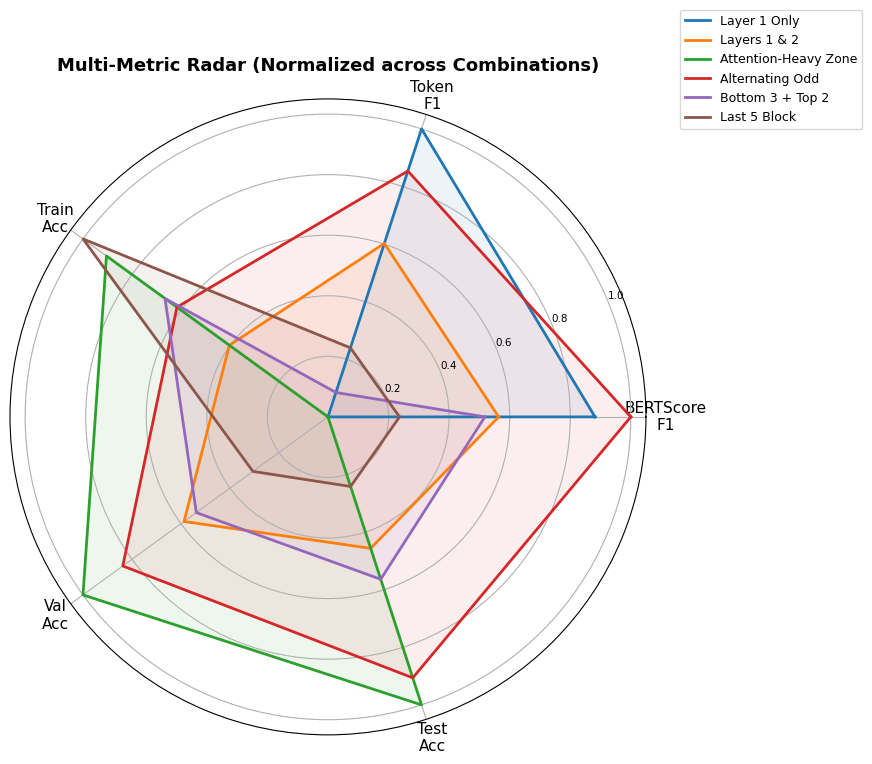

Saved: comparison_radar.png


In [ ]:
from matplotlib.patches import FancyArrowPatch

metrics_keys   = ['bert_f1', 'token_f1', 'train_token_acc', 'val_token_acc', 'test_token_acc']
metrics_labels = ['BERTScore\nF1', 'Token\nF1', 'Train\nAcc', 'Val\nAcc', 'Test\nAcc']
N              = len(metrics_keys)

# Collect raw values per experiment
raw = {}
for r in all_results:
    raw[r['name']] = [r['bert_f1'], r['token_f1'],
                      r['train_token_acc'], r['val_token_acc'], r['test_token_acc']]

# Normalize 0-1 across experiments per metric
col_min = [min(raw[k][i] for k in raw) for i in range(N)]
col_max = [max(raw[k][i] for k in raw) for i in range(N)]

def normalize(vals):
    return [(v - col_min[i]) / max(col_max[i] - col_min[i], 1e-9)
            for i, v in enumerate(vals)]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
palette = plt.cm.tab10.colors

for idx, r in enumerate(all_results):
    vals  = normalize(raw[r['name']])
    vals += vals[:1]
    ax.plot(angles, vals, color=palette[idx], linewidth=2, label=r['name'])
    ax.fill(angles, vals, color=palette[idx], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7.5)
ax.set_title('Multi-Metric Radar (Normalized across Combinations)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_radar.png')


## 15. Final Analysis & Recommendation

In [ ]:
print('=' * 70)
print('FINAL ANALYSIS — LAYER COMBINATION COMPARISON')
print('=' * 70)
print(f'Zero-Shot Baseline  — BERTScore F1: {ZERO_SHOT_BERT_F1}%  '
      f'Token F1: {ZERO_SHOT_TOKEN_F1}%')
print()

# Rank by BERTScore F1
ranked = sorted(all_results, key=lambda r: r['bert_f1'], reverse=True)

print('Ranking by BERTScore F1:')
for rank, r in enumerate(ranked, 1):
    delta = r['bert_f1'] - ZERO_SHOT_BERT_F1
    tag   = '✓ BEATS ZERO-SHOT' if delta > 0 else '✗ BELOW ZERO-SHOT'
    print(f'  #{rank} {r["name"]:25s}  BERTScore F1={r["bert_f1"]:6.2f}%  '
          f'Δ={delta:+.2f}%  TrainAcc={r["train_token_acc"]:6.2f}%  {tag}')

print()
best   = ranked[0]
delta  = best['bert_f1'] - ZERO_SHOT_BERT_F1
print('WINNER ►', best['name'])
print(f'  Layers     : {best["human_layers"]}')
print(f'  Description: {best["description"]}')
print(f'  BERTScore F1 surge : {delta:+.2f}% over zero-shot')
print(f'  Token F1           : {best["token_f1"]}%')
print(f'  Train Accuracy     : {best["train_token_acc"]}%')
print(f'  Val   Accuracy     : {best["val_token_acc"]}%')
print(f'  Test  Accuracy     : {best["test_token_acc"]}%')
print()

# Save complete JSON summary
summary = {
    'zero_shot_bert_f1' : ZERO_SHOT_BERT_F1,
    'zero_shot_token_f1': ZERO_SHOT_TOKEN_F1,
    'winner'            : best['name'],
    'winner_delta_bert' : delta,
    'results'           : all_results,
}
Path('layer_comparison_summary.json').write_text(
    json_module.dumps(summary, indent=2), encoding='utf-8')
print('Full summary saved to layer_comparison_summary.json')
print('PNGs saved: comparison_bert_f1.png, comparison_token_f1.png,')
print('            comparison_accuracy.png, comparison_surge.png,')
print('            comparison_loss_curves.png, comparison_radar.png')


FINAL ANALYSIS — LAYER COMBINATION COMPARISON
Zero-Shot Baseline  — BERTScore F1: 82.26%  Token F1: 16.23%

Ranking by BERTScore F1:
  #1 Alternating Odd            BERTScore F1= 84.32%  Δ=+2.06%  TrainAcc= 77.66%  ✓ BEATS ZERO-SHOT
  #2 Layer 1 Only               BERTScore F1= 84.19%  Δ=+1.93%  TrainAcc= 70.20%  ✓ BEATS ZERO-SHOT
  #3 Layers 1 & 2               BERTScore F1= 83.84%  Δ=+1.58%  TrainAcc= 75.07%  ✓ BEATS ZERO-SHOT
  #4 Bottom 3 + Top 2           BERTScore F1= 83.79%  Δ=+1.53%  TrainAcc= 78.25%  ✓ BEATS ZERO-SHOT
  #5 Last 5 Block               BERTScore F1= 83.48%  Δ=+1.22%  TrainAcc= 82.30%  ✓ BEATS ZERO-SHOT
  #6 Attention-Heavy Zone       BERTScore F1= 83.22%  Δ=+0.96%  TrainAcc= 81.14%  ✓ BEATS ZERO-SHOT

WINNER ► Alternating Odd
  Layers     : [1, 3, 5, 7, 9]
  Description: Layers 1,3,5,7,9: skip-pattern through bottom half
  BERTScore F1 surge : +2.06% over zero-shot
  Token F1           : 30.26%
  Train Accuracy     : 77.66%
  Val   Accuracy     : 64.21%
  Test  A